In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC

# MiniLearn — your from-scratch library
# from minilearn.classifiers import LogisticRegression, KNN, GaussianNaiveBayes, DecisionTreeClassifier
# from minilearn.preprocessing import StandardScaler, train_test_split
# from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

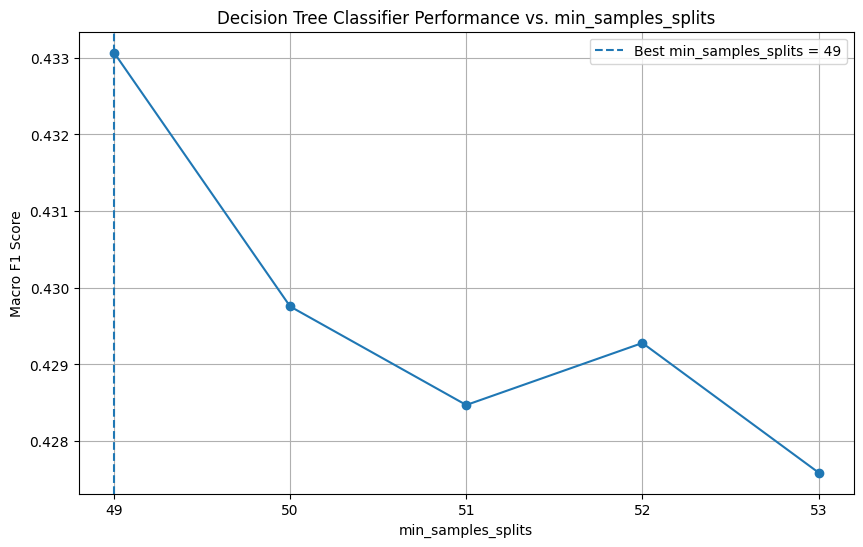

Best max_depths: 49
Best Macro F1: 0.4331


In [3]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_splits = [49, 50, 51, 52, 53]
macro_f1_scores = []

# Baseline model

for min_samples_split in min_samples_splits:
    classifier = DecisionTreeClassifier(min_samples_split=min_samples_split)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_min_samples_splits = min_samples_splits[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_splits, linestyle="--", label=f"Best min_samples_splits = {best_min_samples_splits}")

plt.xlabel("min_samples_splits")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_splits")
plt.xticks(min_samples_splits)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_splits}")
print(f"Best Macro F1: {best_f1:.4f}")

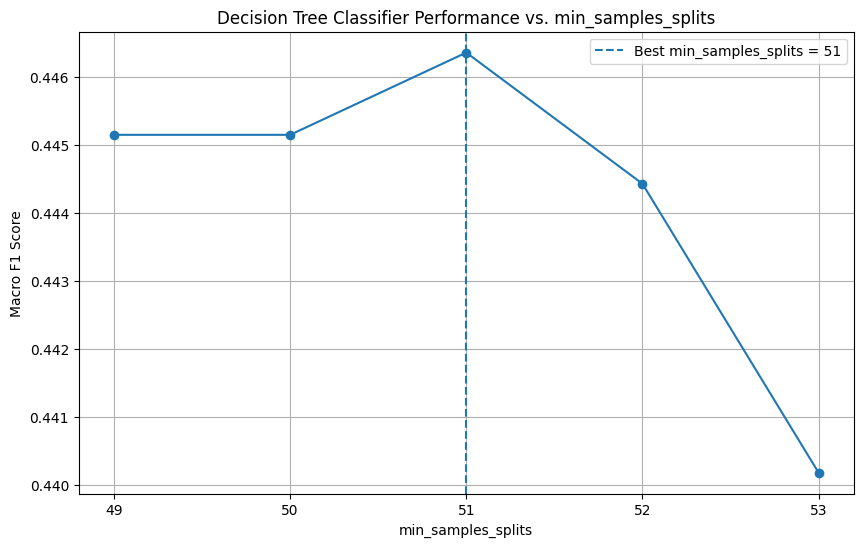

Best max_depths: 51
Best Macro F1: 0.4464


In [4]:
from minilearn.classifiers import DecisionTreeClassifier
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_splits = [49, 50, 51, 52, 53]
macro_f1_scores = []

# Baseline model

for min_samples_split in min_samples_splits:
    classifier = DecisionTreeClassifier(min_samples_split=min_samples_split)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

# Find best k
best_min_samples_splits = min_samples_splits[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_splits, linestyle="--", label=f"Best min_samples_splits = {best_min_samples_splits}")

plt.xlabel("min_samples_splits")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_splits")
plt.xticks(min_samples_splits)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_splits}")
print(f"Best Macro F1: {best_f1:.4f}")

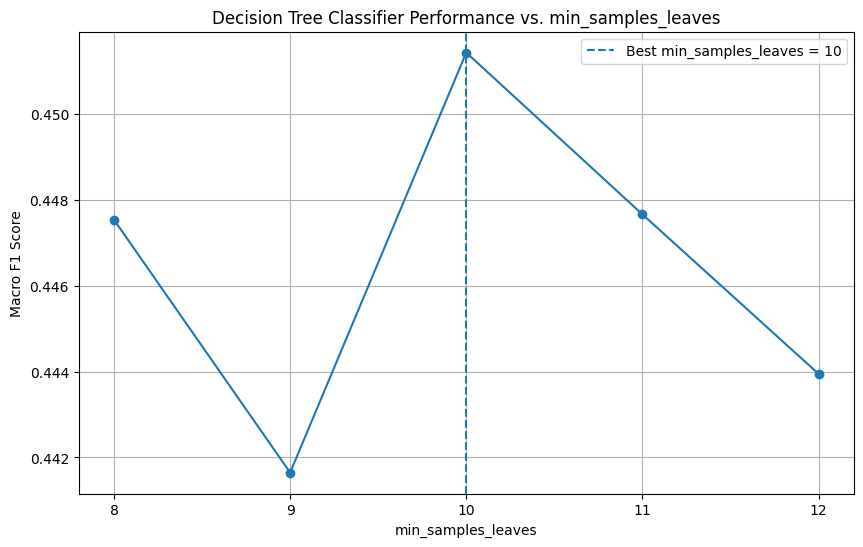

Best max_depths: 10
Best Macro F1: 0.4514


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_leaves = [8, 9, 10, 11, 12]
macro_f1_scores = []

# Baseline model

for min_samples_leaf in min_samples_leaves:
    classifier = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, min_samples_split=51)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_min_samples_leaves = min_samples_leaves[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_leaves, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_leaves, linestyle="--", label=f"Best min_samples_leaves = {best_min_samples_leaves}")

plt.xlabel("min_samples_leaves")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_leaves")
plt.xticks(min_samples_leaves)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_leaves}")
print(f"Best Macro F1: {best_f1:.4f}")

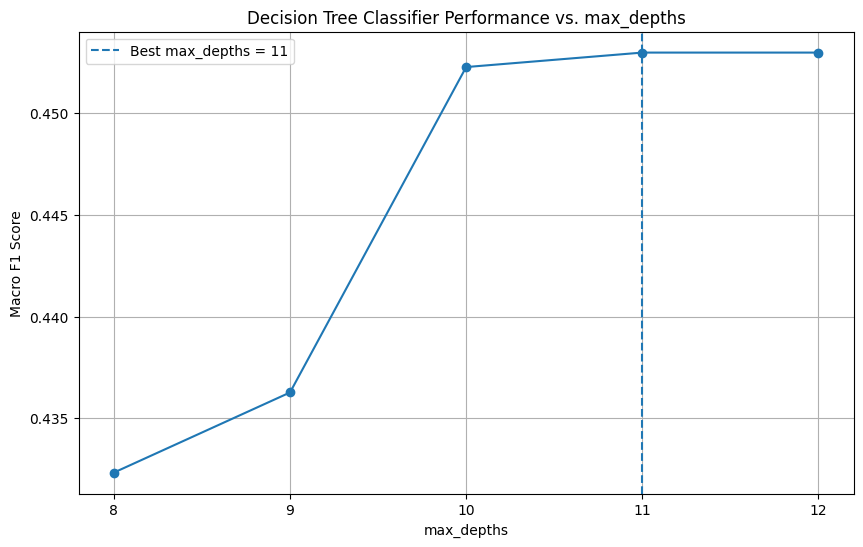

Best max_depths: 11
Best Macro F1: 0.4530


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
max_depths = [8, 9, 10, 11, 12]
macro_f1_scores = []

# Baseline model

for max_depth in max_depths:
    classifier = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=10, min_samples_split=51)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_max_depths = max_depths[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(max_depths, macro_f1_scores, marker="o")
plt.axvline(best_max_depths, linestyle="--", label=f"Best max_depths = {best_max_depths}")

plt.xlabel("max_depths")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. max_depths")
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_max_depths}")
print(f"Best Macro F1: {best_f1:.4f}")

Accuracy: 0.4623217922606925
Precision: 0.4578714902506007
Recall: 0.45540485829959515
Macro F1: 0.4551858131573593
[[36  0  7 15  9  1  5  2]
 [ 0 54  3  1  2  6  9  0]
 [ 0  4 14  3  6  2  5  5]
 [ 8  3  5 23 17  0  9 10]
 [11  4  2 12 27  3 12  4]
 [ 0  2  3  4  3 20  4  2]
 [ 0  7  2  9 12  6 38  1]
 [ 4  2  3  3  5  2  5 15]]


[Text(0.5, 0.8333333333333334, 'x[236] <= -0.22\ngini = 0.864\nsamples = 1961\nvalue = [301, 301, 153, 301, 301, 150, 301, 153]'),
 Text(0.25, 0.5, 'x[150] <= -0.155\ngini = 0.843\nsamples = 1192\nvalue = [36, 294, 124, 132, 122, 139, 238, 107]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[220] <= 0.325\ngini = 0.767\nsamples = 769\nvalue = [265, 7, 29, 169, 179, 11, 63, 46]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

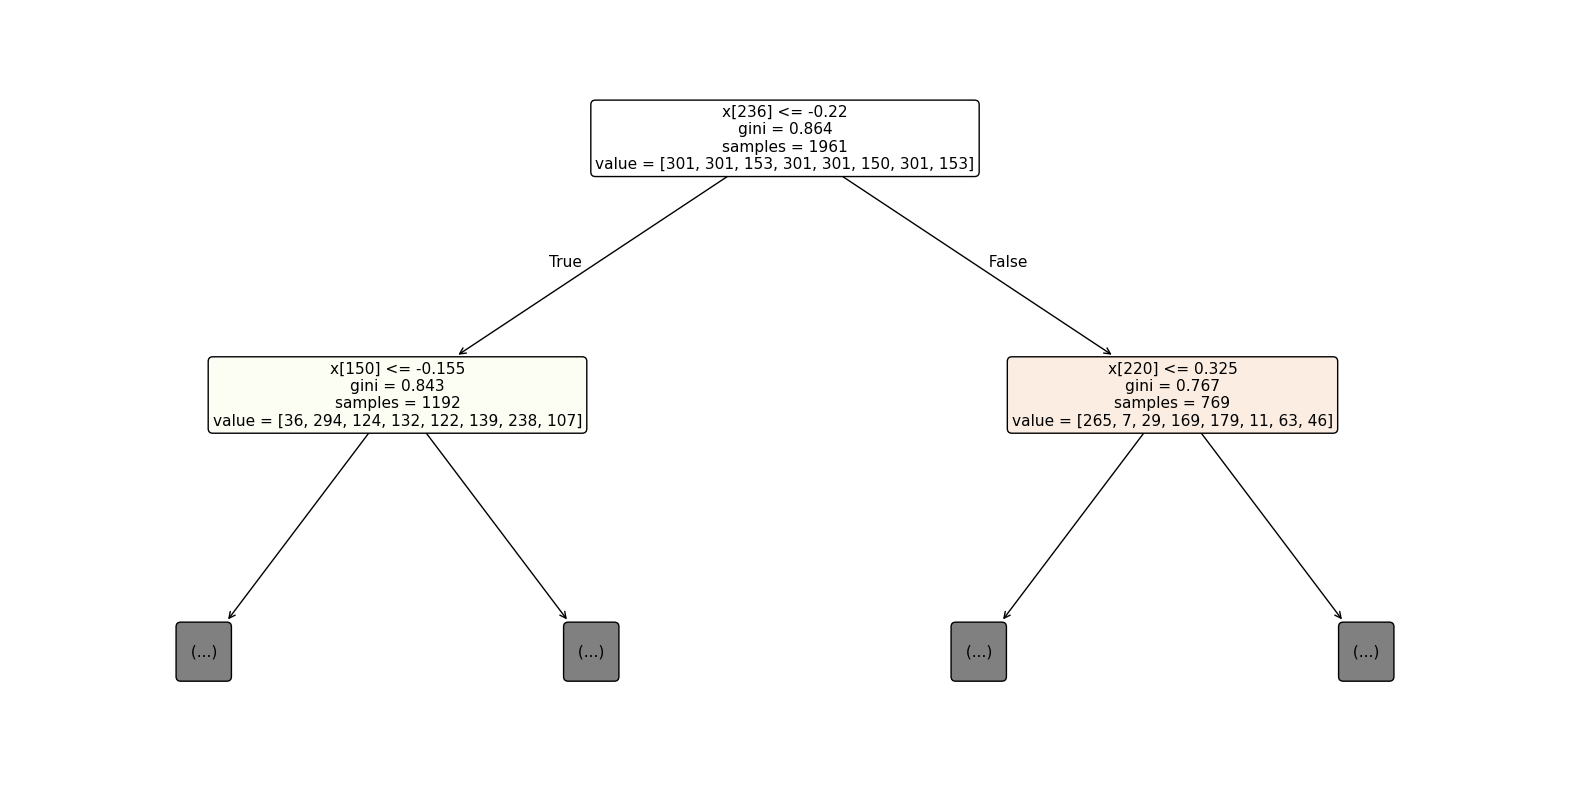

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classifier = DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(classifier, max_depth=1, rounded=True, filled=True)

This is good as a standard decision tree classifier will get with this data, it seems

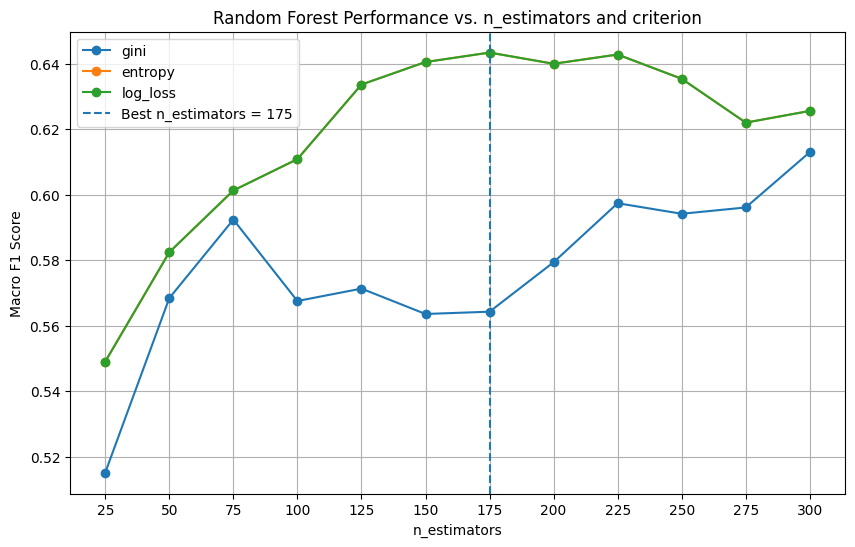

Best criterion: entropy
Best n_estimators: 175
Best Macro F1: 0.6434


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different n_estimators and criteria
n_estimators = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]
criteria = ["gini", "entropy", "log_loss"]

results = {}

for criterion in criteria:
    macro_f1_scores = []

    for n_estimator in n_estimators:
        classifier = RandomForestClassifier(n_estimators=n_estimator, criterion=criterion, random_state=42)

        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)

        macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

    results[criterion] = macro_f1_scores

# Find overall best combination
best_criterion = None
best_n_estimators = None
best_f1 = -1

for criterion, scores in results.items():
    max_score = max(scores)

    if max_score > best_f1:
        best_f1 = max_score
        best_criterion = criterion
        best_n_estimators = n_estimators[scores.index(max_score)]

# Plot performance
plt.figure(figsize=(10, 6))

for criterion, scores in results.items():
    plt.plot(n_estimators, scores, marker="o", label=criterion)

plt.axvline(best_n_estimators, linestyle="--", label=f"Best n_estimators = {best_n_estimators}")

plt.xlabel("n_estimators")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. n_estimators and criterion")
plt.xticks(n_estimators)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best criterion: {best_criterion}")
print(f"Best n_estimators: {best_n_estimators}")
print(f"Best Macro F1: {best_f1:.4f}")

Looks like entropy and log_loss have identical results. I like the name log_loss better.

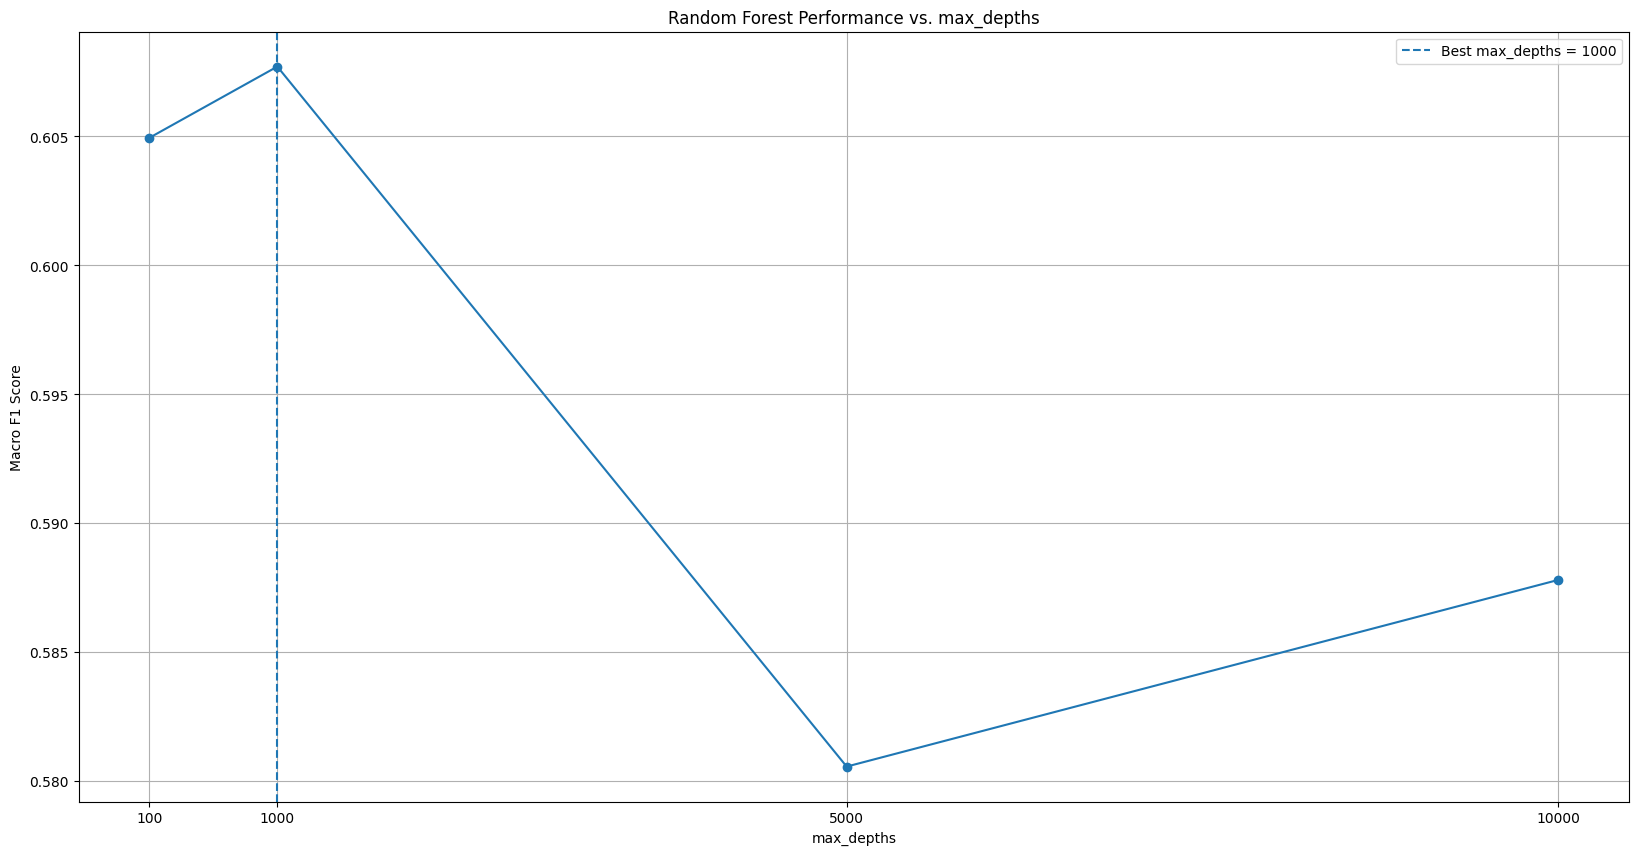

Best max_depths: 1000
Best Macro F1: 0.6077


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
max_depths = [100, 1000, 5000, 10000]
macro_f1_scores = []

# Baseline model

for max_depth in max_depths:
    classifier = RandomForestClassifier(n_estimators=175, criterion="log_loss", max_depth=max_depth)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_max_depths = max_depths[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(20, 10))
plt.plot(max_depths, macro_f1_scores, marker="o")
plt.axvline(best_max_depths, linestyle="--", label=f"Best max_depths = {best_max_depths}")

plt.xlabel("max_depths")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. max_depths")
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_max_depths}")
print(f"Best Macro F1: {best_f1:.4f}")

I can't find a clear max depth that makes any meaningful difference. It's very random. Sometimes 1000 does better, other times 10000

Accuracy: 0.6109979633401222
Precision: 0.6224244531946345
Recall: 0.6039001349527665
Macro F1: 0.6069608641672415
[[52  0  6  4  9  0  1  3]
 [ 0 66  1  2  4  0  2  0]
 [ 1  4 18  0 10  0  4  2]
 [ 9  3  0 40  7  0 11  5]
 [14  6  3  5 42  0  4  1]
 [ 0  3  1  1  2 28  2  1]
 [ 1 20  3  5  6  5 34  1]
 [ 2  3  2  1  8  1  2 20]]


[Text(0.5, 0.8333333333333334, 'x[354] <= -0.168\nlog_loss = 2.908\nsamples = 1234\nvalue = [336, 292, 138, 324, 310, 137, 285, 139]'),
 Text(0.25, 0.5, 'x[208] <= -0.293\nlog_loss = 2.614\nsamples = 533\nvalue = [17.0, 255.0, 40.0, 72.0, 99.0, 125.0, 187.0, 37.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[208] <= -0.172\nlog_loss = 2.607\nsamples = 701\nvalue = [319.0, 37.0, 98.0, 252.0, 211.0, 12.0, 98.0, 102.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

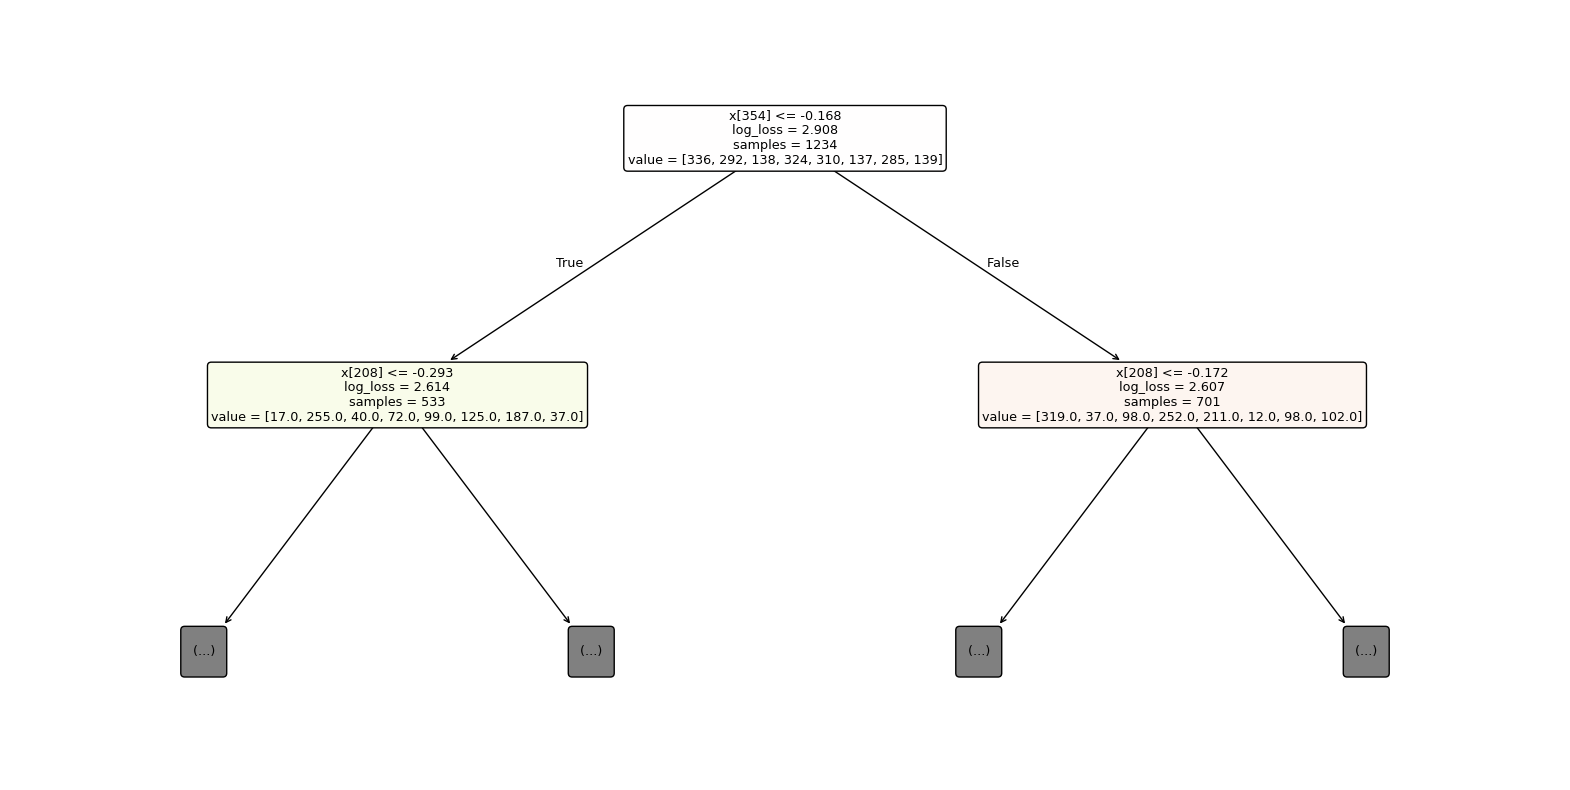

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model

classifier = RandomForestClassifier(n_estimators=175, criterion="log_loss")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(classifier[0], max_depth=1, rounded=True, filled=True)

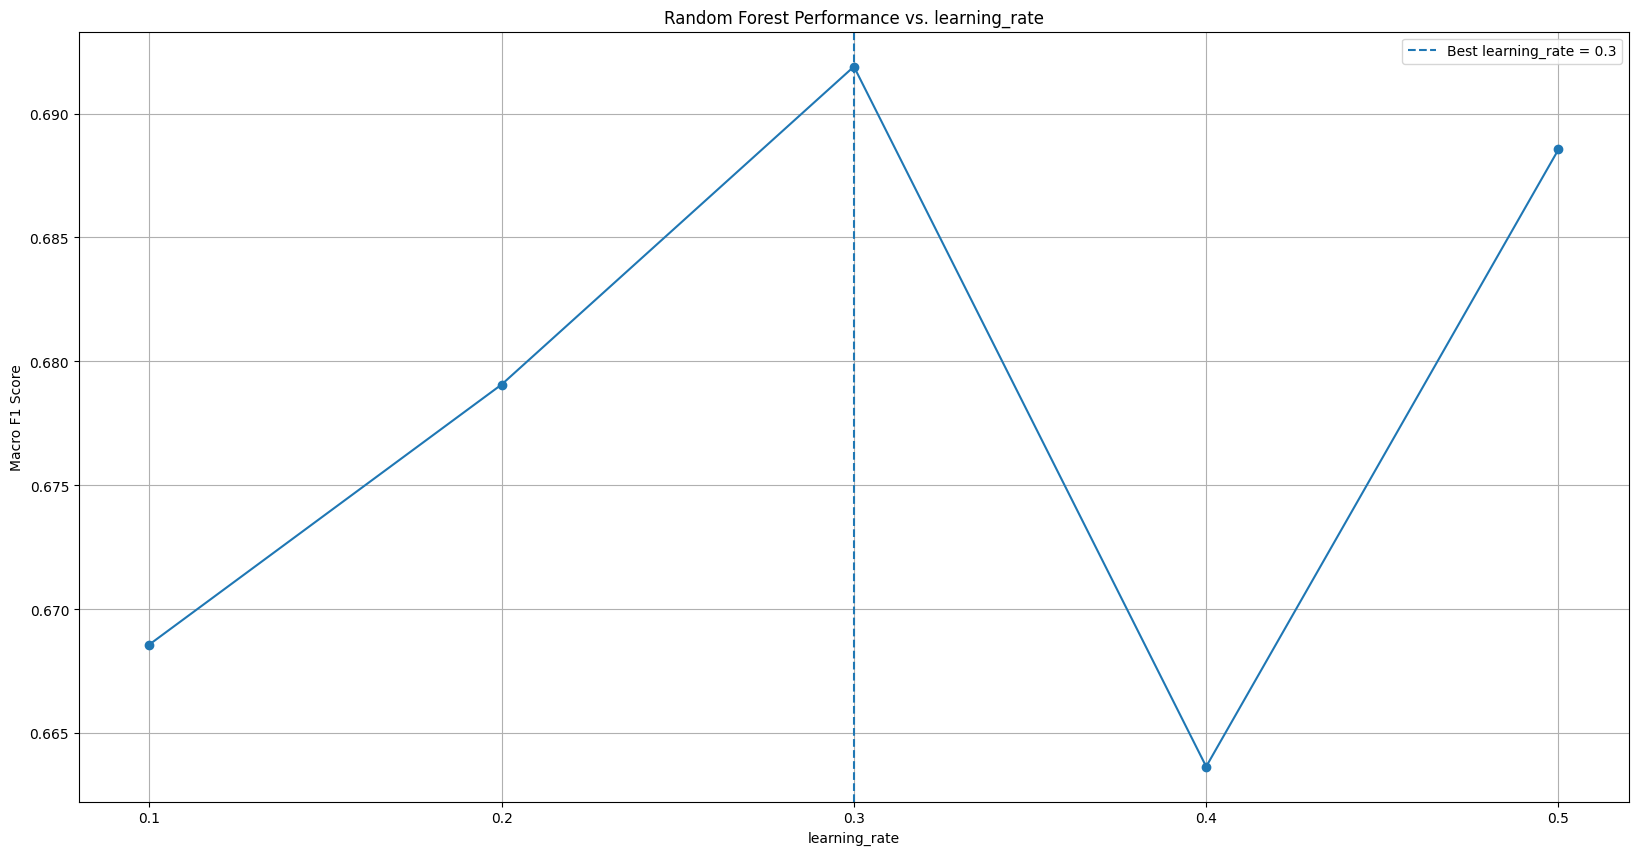

Best learning_rate: 0.3
Best Macro F1: 0.6919


In [ ]:
# Baseline model
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

decision_tree_classifier = DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51)

# Try different k values
learning_rates = [0.1, .2, .3, .4, .5]
macro_f1_scores = []

for learning_rate in learning_rates:
    adaBoost = AdaBoostClassifier(n_estimators=175, estimator=decision_tree_classifier, learning_rate=learning_rate)
    adaBoost.fit(X_train, y_train)
    y_pred = adaBoost.predict(X_test)

    macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

# Find best k
best_learning_rate = learning_rates[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(20, 10))
plt.plot(learning_rates, macro_f1_scores, marker="o")
plt.axvline(best_learning_rate, linestyle="--", label=f"Best learning_rate = {best_learning_rate}")

plt.xlabel("learning_rate")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. learning_rate")
plt.xticks(learning_rates)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best learning_rate: {best_learning_rate}")
print(f"Best Macro F1: {best_f1:.4f}")

.3 Is looking pretty good.